# exp_002 — Quantization with llama.cpp GGUF

This notebook loads the strongest available measured summary. When the resolved full manifest, complete capability summary, and separate 3–5 repeat timing summary are all present, an unqualified run selects full automatically; otherwise it displays the committed v002 pilot. Set `EXP002_PHASE=full` to require the full artifacts explicitly, or `EXP002_PHASE=pilot` to inspect the pilot. It never invents missing variant measurements.

Capability outcomes and systems costs are separate. Speed fields are stream-derived proxies; native prefill/decode counters are unavailable. RSS is sampled within the process and is not a definitive cross-variant memory comparison when variants are loaded sequentially. The pilot is one greedy run per independent task; repeated greedy prompts are not independent accuracy samples. Timing repeats are stored separately and are used only for systems-cost medians.

In [1]:
import hashlib
import json
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'src').is_dir() and (candidate / 'experiments').is_dir())
EXPERIMENT_ROOT = ROOT / 'experiments/exp_002-quantization_llama_cpp_gguf'
RESULTS_DIR = Path(os.environ.get('EXP002_RESULTS_DIR', ROOT / 'experiments/exp_002-quantization_llama_cpp_gguf/results'))
SUMMARY_PATH = RESULTS_DIR / 'processed/summary.csv'
PILOT_SUMMARY_PATH = RESULTS_DIR / 'processed/pilot-v002-summary.csv'
TIMING_SUMMARY_PATH = Path(os.environ.get('EXP002_TIMING_SUMMARY_PATH', RESULTS_DIR / 'processed/timing-summary.csv'))
REQUESTED_PHASE = os.environ.get('EXP002_PHASE')
FULL_MANIFEST_PATH = RESULTS_DIR / 'manifest.full.json'
if REQUESTED_PHASE is None:
    PHASE = 'full' if FULL_MANIFEST_PATH.is_file() and SUMMARY_PATH.is_file() and TIMING_SUMMARY_PATH.is_file() else 'pilot'
else:
    PHASE = REQUESTED_PHASE
if 'EXP002_MANIFEST_PATH' in os.environ:
    MANIFEST_PATH = Path(os.environ['EXP002_MANIFEST_PATH'])
else:
    MANIFEST_PATH = RESULTS_DIR / ('manifest.full.json' if PHASE == 'full' else 'manifest.json')
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(f'resolved manifest is required: {MANIFEST_PATH}')
if PHASE == 'full':
    if not SUMMARY_PATH.is_file():
        raise FileNotFoundError(f'complete measured summary is required: {SUMMARY_PATH}')
    selected_summary_path = SUMMARY_PATH
elif PHASE == 'pilot':
    if not PILOT_SUMMARY_PATH.is_file():
        raise FileNotFoundError(f'pilot summary is required: {PILOT_SUMMARY_PATH}')
    selected_summary_path = PILOT_SUMMARY_PATH
else:
    raise ValueError("EXP002_PHASE must be 'pilot' or 'full'")
sys.path.insert(0, str(ROOT / 'src'))
from llm_lab.analysis import task_level_wilson
from llm_lab.analysis.quantization import recommend_baseline, tradeoff_rows, validate_complete_quantization_matrix, QuantizationAnalysisError
from llm_lab.quantization import QuantizationManifest
manifest_record = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
manifest = QuantizationManifest.from_record(manifest_record)
if manifest_record.get('controls', {}).get('scorer_version') != 'calibrated.v1':
    raise ValueError("resolved manifest scorer policy must be 'calibrated.v1'")
if PHASE == 'full' and manifest.capability_repeats != 1:
    raise ValueError('full conclusion requires a freshly resolved manifest with capability_repeats=1')
summaries = pd.read_csv(selected_summary_path)
def _verify_raw_provenance(frame, *, path_column, hash_column, override_path, label):
    required = {path_column, hash_column}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'{label} summary is missing raw provenance columns: {sorted(missing)}')
    paths = {str(value) for value in frame[path_column].dropna()}
    hashes = {str(value) for value in frame[hash_column].dropna()}
    if len(paths) != 1 or len(hashes) != 1:
        raise ValueError(f'{label} summary must contain one raw path and one raw SHA-256')
    raw_path = Path(os.environ.get(override_path, next(iter(paths))))
    if not raw_path.is_file():
        raise FileNotFoundError(f'{label} raw results are missing: {raw_path}')
    digest = hashlib.sha256()
    with raw_path.open('rb') as raw_file:
        for chunk in iter(lambda: raw_file.read(1024 * 1024), b''):
            digest.update(chunk)
    expected_hash = next(iter(hashes))
    if digest.hexdigest() != expected_hash:
        raise ValueError(f'{label} raw SHA-256 mismatch: expected {expected_hash}, found {digest.hexdigest()}')
    return raw_path, expected_hash
if PHASE == 'full':
    _verify_raw_provenance(summaries, path_column='raw_results', hash_column='raw_results_sha256', override_path='EXP002_RAW_PATH', label='capability')
if PHASE == 'full':
    if not TIMING_SUMMARY_PATH.is_file():
        raise FileNotFoundError(f'separate timing summary is required for full analysis: {TIMING_SUMMARY_PATH}')
    timing_summaries = pd.read_csv(TIMING_SUMMARY_PATH)
    _verify_raw_provenance(timing_summaries, path_column='timing_raw_results', hash_column='timing_raw_results_sha256', override_path='EXP002_TIMING_RAW_PATH', label='timing')
    if 'scorer_version' not in timing_summaries.columns or timing_summaries['scorer_version'].isna().any() or set(timing_summaries['scorer_version'].astype(str)) != {'calibrated.v1'}:
        raise ValueError("timing summary scorer policy must be 'calibrated.v1'")
    if manifest.timing_repeats is None or not 3 <= manifest.timing_repeats <= 5:
        raise ValueError('full analysis requires manifest timing_repeats between 3 and 5')
    timing_required = {'variant_condition_id', 'task_id', 'target_context_tokens', 'attempted_n', 'median_stream_ttft_s', 'median_prompt_throughput_proxy_tok_s', 'median_post_first_chunk_output_tok_s', 'median_peak_memory_bytes'}
    missing_timing = timing_required - set(timing_summaries.columns)
    if missing_timing:
        raise ValueError(f'timing summary is missing required columns: {sorted(missing_timing)}')
    observed_timing_repeats = set(pd.to_numeric(timing_summaries['attempted_n']).astype(int))
    if observed_timing_repeats != {manifest.timing_repeats}:
        raise ValueError(f'timing summary repeat counts must equal manifest timing_repeats={manifest.timing_repeats}; found {sorted(observed_timing_repeats)}')
    timing_keys = ['variant_condition_id', 'task_id', 'target_context_tokens']
    timing_metric_columns = ['median_stream_ttft_s', 'median_prompt_throughput_proxy_tok_s', 'median_post_first_chunk_output_tok_s', 'median_peak_memory_bytes']
    timing_frame = timing_summaries[timing_keys + timing_metric_columns]
    if timing_frame.duplicated(timing_keys).any():
        raise ValueError('timing summary contains duplicate variant/task/context cells')
    capability_keys = set(map(tuple, summaries[timing_keys].astype(str).to_numpy()))
    timing_key_set = set(map(tuple, timing_frame[timing_keys].astype(str).to_numpy()))
    if capability_keys != timing_key_set:
        missing_timing_keys = sorted(capability_keys - timing_key_set)
        unexpected_timing_keys = sorted(timing_key_set - capability_keys)
        raise ValueError(
            'capability and timing summaries must have identical variant/task/context cells; '
            f'missing_timing={missing_timing_keys[:10]}, '
            f'unexpected_timing={unexpected_timing_keys[:10]}'
        )
    summaries = summaries.drop(columns=timing_metric_columns, errors='ignore').merge(timing_frame, on=timing_keys, how='left', validate='one_to_one')
    if summaries[timing_metric_columns].isna().any().any():
        raise ValueError('matched timing probe cells are missing required metrics')
EXPECTED_SCORER = 'calibrated.v1'
if 'scorer_version' not in summaries.columns or summaries['scorer_version'].isna().any() or set(summaries['scorer_version'].astype(str)) != {EXPECTED_SCORER}:
    raise ValueError("summary scorer policy must be 'calibrated.v1'; legacy summaries are not valid")
required_columns = {'condition_id', 'variant_condition_id', 'task_id', 'target_context_tokens', 'attempted_n', 'scored_n', 'correct_n', 'exact_correct_n', 'exact_scored_n', 'exact_accuracy', 'scored_accuracy', 'answer_bearing_correct_n', 'answer_bearing_scored_n', 'answer_bearing_accuracy', 'format_valid_n', 'format_scored_n', 'format_validity', 'end_to_end_success', 'failure_rate'}
if PHASE != 'full':
    required_columns |= {'median_stream_ttft_s', 'median_prompt_throughput_proxy_tok_s', 'median_post_first_chunk_output_tok_s', 'median_peak_memory_bytes'}
missing_columns = required_columns - set(summaries.columns)
if missing_columns:
    raise ValueError(f'summary is missing required columns: {sorted(missing_columns)}')
task_uncertainty = task_level_wilson(
    summaries.to_dict('records'),
    group_keys=('variant_condition_id', 'task_type', 'target_context_tokens'),
    metric_fields={'end_to_end': 'correct_n', 'exact': 'exact_correct_n', 'answer_bearing': 'answer_bearing_correct_n', 'format_valid': 'format_valid_n'},
)
declared_conditions = {variant.condition_id for variant in manifest.variants}
observed_conditions = set(summaries.get('variant_condition_id', summaries['condition_id']).astype(str))
claim_blockers = []
if PHASE != 'full': claim_blockers.append('full phase is required for a quantization conclusion')
if observed_conditions != declared_conditions: claim_blockers.append('all declared Q8/Q6/Q5/Q4 variants must be measured')
if PHASE == 'full':
    try:
        validate_complete_quantization_matrix(summaries.to_dict('records'), manifest)
    except QuantizationAnalysisError as error:
        claim_blockers.append(str(error))
claim_ready = not claim_blockers
print({'phase': PHASE, 'summary': str(selected_summary_path), 'timing_summary': str(TIMING_SUMMARY_PATH) if PHASE == 'full' else None, 'rows': len(summaries), 'measured_conditions': sorted(observed_conditions), 'claim_ready': claim_ready, 'claim_blockers': claim_blockers})

{'phase': 'pilot', 'summary': '/Users/shotomorisaki/Engineering/qwen-meetup-tokyo/experiments/exp_002-quantization_llama_cpp_gguf/results/processed/pilot-v002-summary.csv', 'timing_summary': None, 'rows': 30, 'measured_conditions': ['q8_0'], 'claim_ready': False, 'claim_blockers': ['full phase is required for a quantization conclusion', 'all declared Q8/Q6/Q5/Q4 variants must be measured']}


In [2]:
def _measured_rows(summary_frame):
    rows = []
    for condition_id, group in summary_frame.groupby(summary_frame.get('variant_condition_id', summary_frame['condition_id']).astype(str)):
        attempted = int(group['attempted_n'].sum())
        scored = int(group['scored_n'].sum())
        correct = int(group['correct_n'].sum())
        failures = int(group['failure_n'].sum()) if 'failure_n' in group else attempted - scored
        variant = next((item for item in manifest.variants if item.condition_id == condition_id), None)
        if variant is None:
            continue
        answer_bearing_scored = int(group['answer_bearing_scored_n'].sum())
        answer_bearing_correct = int(group['answer_bearing_correct_n'].sum())
        format_scored = int(group['format_scored_n'].sum())
        format_valid = int(group['format_valid_n'].sum())
        exact_correct = int(group['exact_correct_n'].sum()) if 'exact_correct_n' in group else correct
        exact_scored = int(group['exact_scored_n'].sum()) if 'exact_scored_n' in group else scored
        rows.append({'condition_id': condition_id, 'label': variant.label, 'artifact_size_bytes': variant.artifact.artifact_size_bytes, 'median_peak_memory_bytes': float(group['median_peak_memory_bytes'].median()), 'median_stream_ttft_s': float(group['median_stream_ttft_s'].median()), 'median_prompt_throughput_proxy_tok_s': float(group['median_prompt_throughput_proxy_tok_s'].median()), 'median_post_first_chunk_output_tok_s': float(group['median_post_first_chunk_output_tok_s'].median()), 'attempted_n': attempted, 'scored_n': scored, 'correct_n': correct, 'exact_correct_n': exact_correct, 'exact_scored_n': exact_scored, 'exact_accuracy': exact_correct / exact_scored if exact_scored else None, 'failure_n': failures, 'scored_accuracy': correct / scored if scored else None, 'answer_bearing_correct_n': answer_bearing_correct, 'answer_bearing_scored_n': answer_bearing_scored, 'answer_bearing_accuracy': answer_bearing_correct / answer_bearing_scored if answer_bearing_scored else None, 'format_valid_n': format_valid, 'format_scored_n': format_scored, 'format_validity': format_valid / format_scored if format_scored else None, 'end_to_end_success': correct / attempted if attempted else None, 'failure_rate': failures / attempted if attempted else None})
    return rows

if PHASE == 'full':
    rows = tradeoff_rows(summaries.to_dict('records'), manifest, require_complete=True)
else:
    rows = _measured_rows(summaries)
frame = pd.DataFrame(rows)
capability_frame = frame[['condition_id', 'attempted_n', 'scored_n', 'correct_n', 'exact_correct_n', 'exact_scored_n', 'exact_accuracy', 'answer_bearing_correct_n', 'answer_bearing_scored_n', 'answer_bearing_accuracy', 'format_valid_n', 'format_scored_n', 'format_validity', 'end_to_end_success', 'failure_rate']].sort_values('condition_id')
systems_cost_frame = frame[['condition_id', 'artifact_size_bytes', 'median_peak_memory_bytes', 'median_stream_ttft_s', 'median_prompt_throughput_proxy_tok_s', 'median_post_first_chunk_output_tok_s']].sort_values('condition_id')
accuracy_vs_memory = capability_frame.merge(systems_cost_frame[['condition_id', 'artifact_size_bytes']], on='condition_id')
speed_vs_memory = systems_cost_frame[['condition_id', 'artifact_size_bytes', 'median_stream_ttft_s', 'median_prompt_throughput_proxy_tok_s', 'median_post_first_chunk_output_tok_s']]
display(capability_frame)
display(systems_cost_frame)
display(pd.DataFrame(task_uncertainty))
print('Wilson intervals use independent task IDs; runtime/invalid-output attempts remain in the denominator.')
if PHASE == 'pilot':
    print('This is a Q8_0-only pilot: no cross-quantization recommendation is valid yet.')

,condition_id,attempted_n,scored_n,correct_n,exact_correct_n,exact_scored_n,exact_accuracy,answer_bearing_correct_n,answer_bearing_scored_n,answer_bearing_accuracy,format_valid_n,format_scored_n,format_validity,end_to_end_success,failure_rate
0,q8_0,30,30,14,14,30,0.466667,30,30,1.0,19,30,0.633333,0.466667,0.0


,condition_id,artifact_size_bytes,median_peak_memory_bytes,median_stream_ttft_s,median_prompt_throughput_proxy_tok_s,median_post_first_chunk_output_tok_s
0,q8_0,29047084256,3.122490e+10,71.173999,115.709402,7.967115


,variant_condition_id,task_type,target_context_tokens,task_n,attempted_n,end_to_end_success_n,end_to_end_rate,end_to_end_ci_low,end_to_end_ci_high,exact_success_n,...,exact_ci_low,exact_ci_high,answer_bearing_success_n,answer_bearing_rate,answer_bearing_ci_low,answer_bearing_ci_high,format_valid_success_n,format_valid_rate,format_valid_ci_low,format_valid_ci_high
0,q8_0,literal_retrieval,8192,10,10,2,0.2,0.056681,0.509843,2,...,0.056681,0.509843,10,1.0,0.72246,1.0,2,0.2,0.056681,0.509843
1,q8_0,multi_hop,8192,10,10,8,0.8,0.490157,0.943319,8,...,0.490157,0.943319,10,1.0,0.72246,1.0,8,0.8,0.490157,0.943319
2,q8_0,semantic_retrieval,8192,10,10,4,0.4,0.168178,0.687330,4,...,0.168178,0.687330,10,1.0,0.72246,1.0,9,0.9,0.595844,0.982124


Wilson intervals use independent task IDs; runtime/invalid-output attempts remain in the denominator.
This is a Q8_0-only pilot: no cross-quantization recommendation is valid yet.


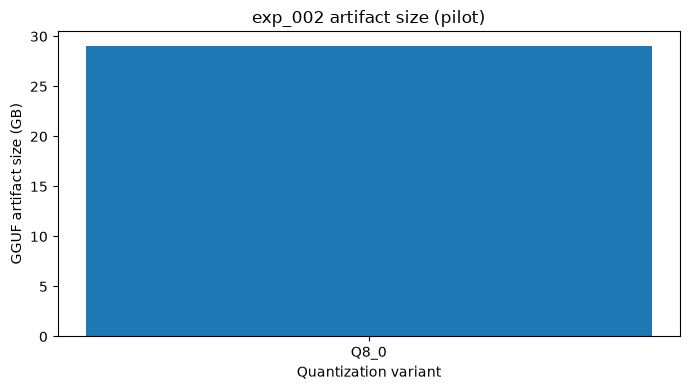

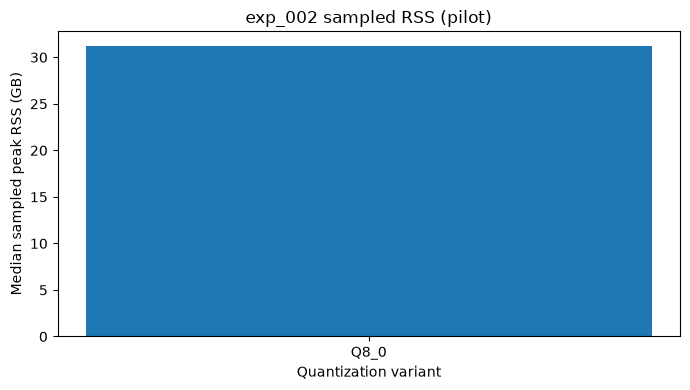

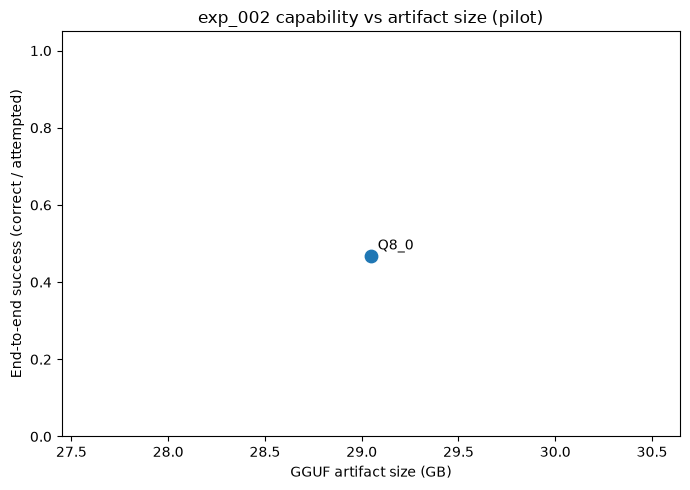

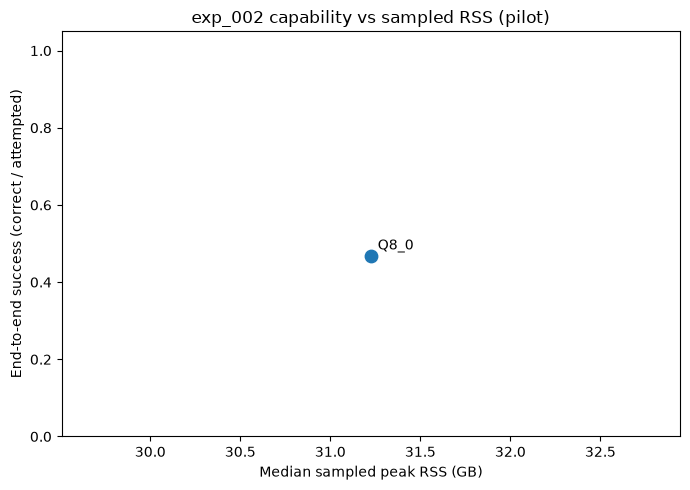

,variant_condition_id,target_context_tokens,median_stream_ttft_s,median_prompt_throughput_proxy_tok_s,median_post_first_chunk_output_tok_s
0,q8_0,8192,71.173999,115.709402,7.967115


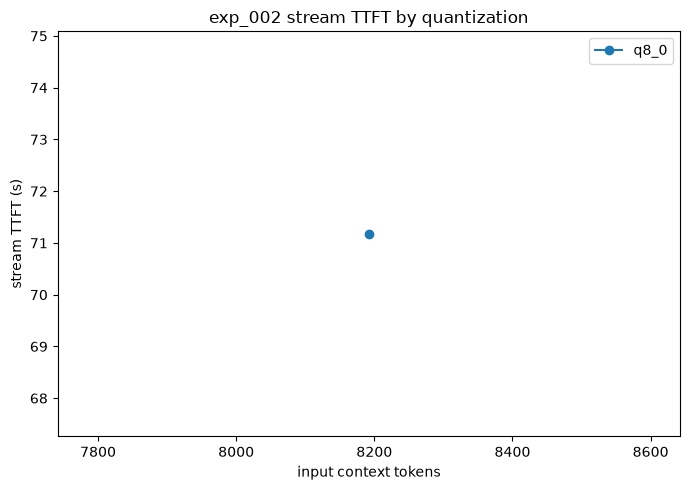

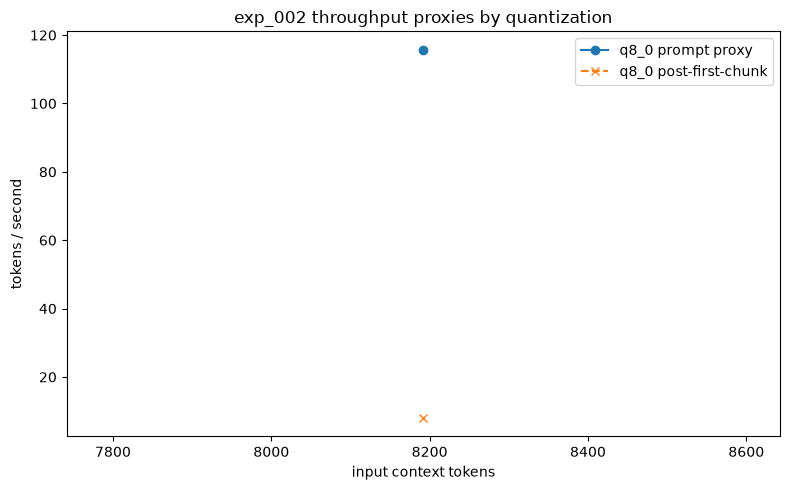

In [3]:
RESULTS_DIR.joinpath('figures').mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(frame['label'], frame['artifact_size_bytes'] / 1e9)
ax.set_xlabel('Quantization variant')
ax.set_ylabel('GGUF artifact size (GB)')
ax.set_title(f'exp_002 artifact size ({PHASE})')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'figures' / 'artifact-size-by-variant.png', dpi=160, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(frame['label'], frame['median_peak_memory_bytes'] / 1e9)
ax.set_xlabel('Quantization variant')
ax.set_ylabel('Median sampled peak RSS (GB)')
ax.set_title(f'exp_002 sampled RSS ({PHASE})')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'figures' / 'rss-by-variant.png', dpi=160, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(frame['artifact_size_bytes'] / 1e9, frame['end_to_end_success'], s=80)
for _, row in frame.iterrows():
    ax.annotate(row['label'], (row['artifact_size_bytes'] / 1e9, row['end_to_end_success']), xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('GGUF artifact size (GB)')
ax.set_ylabel('End-to-end success (correct / attempted)')
ax.set_ylim(0, 1.05)
ax.set_title(f'exp_002 capability vs artifact size ({PHASE})')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'figures' / 'success-vs-artifact-size.png', dpi=160, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(frame['median_peak_memory_bytes'] / 1e9, frame['end_to_end_success'], s=80)
for _, row in frame.iterrows():
    ax.annotate(row['label'], (row['median_peak_memory_bytes'] / 1e9, row['end_to_end_success']), xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Median sampled peak RSS (GB)')
ax.set_ylabel('End-to-end success (correct / attempted)')
ax.set_ylim(0, 1.05)
ax.set_title(f'exp_002 capability vs sampled RSS ({PHASE})')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'figures' / 'accuracy-vs-rss.png', dpi=160, bbox_inches='tight')
plt.show()

if 'target_context_tokens' in summaries.columns:
    timing = summaries.groupby(['variant_condition_id', 'target_context_tokens'], as_index=False)[['median_stream_ttft_s', 'median_prompt_throughput_proxy_tok_s', 'median_post_first_chunk_output_tok_s']].median()
    display(timing)
    fig, ax = plt.subplots(figsize=(7, 5))
    for variant_id, group in timing.groupby('variant_condition_id'):
        ax.plot(group['target_context_tokens'], group['median_stream_ttft_s'], marker='o', label=variant_id)
    ax.set_xlabel('input context tokens')
    ax.set_ylabel('stream TTFT (s)')
    ax.set_title('exp_002 stream TTFT by quantization')
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'figures' / 'ttft-vs-context.png', dpi=160, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    for variant_id, group in timing.groupby('variant_condition_id'):
        ax.plot(group['target_context_tokens'], group['median_prompt_throughput_proxy_tok_s'], marker='o', label=f'{variant_id} prompt proxy')
        ax.plot(group['target_context_tokens'], group['median_post_first_chunk_output_tok_s'], marker='x', linestyle='--', label=f'{variant_id} post-first-chunk')
    ax.set_xlabel('input context tokens')
    ax.set_ylabel('tokens / second')
    ax.set_title('exp_002 throughput proxies by quantization')
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'figures' / 'throughput-vs-context.png', dpi=160, bbox_inches='tight')
    plt.show()

In [4]:
if PHASE == 'full':
    recommendation = recommend_baseline(rows, accuracy_tolerance=0.02)
    print({'recommended_condition': recommendation['condition_id'], 'recommended_label': recommendation['label'], 'end_to_end_success': recommendation['end_to_end_success'], 'artifact_size_bytes': recommendation['artifact_size_bytes'], 'accuracy_tolerance': recommendation['accuracy_tolerance']})
else:
    print('Recommendation withheld: complete Q8/Q6/Q5/Q4 capability coverage is required.')

Recommendation withheld: complete Q8/Q6/Q5/Q4 capability coverage is required.
